# Notebook 4 — Comprehensive Analysis, Ablations & Robustness Studies

This notebook elevates the project from a demonstration to **research-grade experimental methodology**.

**Contents**:
1. **Statistical evaluation** — Monte Carlo over random masks with error bars
2. **Acceleration sweep** — all methods compared across R = 2, 4, 6, 8
3. **Noise robustness** — reconstruction quality vs measurement SNR
4. **Convergence rate analysis** — empirical O(1/k) vs O(1/k²) verification
5. **ROI zoom-in analysis** — fine-detail comparison at sub-pixel level
6. **PSF analysis** — point spread function of the undersampling pattern
7. **Ablation: shared vs per-layer proximal operators**
8. **Summary results table** — publication-ready comparison

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pywt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from skimage.data import shepp_logan_phantom
from skimage.transform import resize
from skimage.metrics import structural_similarity as ssim_sk

np.random.seed(42)
torch.manual_seed(42)

if torch.cuda.is_available():
    device = "cuda"
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Device: {device}")

plt.rcParams.update({
    "figure.dpi": 130, "savefig.dpi": 250, "font.size": 11,
    "axes.titlesize": 13, "axes.labelsize": 11, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
})

Device: mps


In [4]:
# Phantom
image_np = shepp_logan_phantom()
image_np = resize(image_np, (256, 256), anti_aliasing=True).astype(np.float32)
N = image_np.shape[0]

# shared utils
def random_cartesian_mask(N, accel=4, center_frac=0.08, rng=None):
    if rng is None: rng = np.random.default_rng()
    mask = np.zeros((N, N), dtype=np.float32)
    c = max(1, int((center_frac * N) / 2))
    center_cols = np.concatenate([np.arange(0, c), np.arange(N - c, N)])
    num_cols = max(len(center_cols), N // accel)
    remaining = num_cols - len(center_cols)
    candidates = np.setdiff1d(np.arange(N), center_cols)
    if remaining > 0:
        pick = rng.choice(candidates, size=remaining, replace=False)
        cols = np.concatenate([center_cols, pick])
    else:
        cols = center_cols
    mask[:, cols] = 1.0
    return mask

def A_np(x, mask): return mask * np.fft.fft2(x, norm="ortho")
def AT_np(y, mask): return np.fft.ifft2(y * mask, norm="ortho")

def A_torch(x, mask): return torch.fft.fft2(x.squeeze(1), norm="ortho") * mask
def AT_torch(y, mask): return torch.fft.ifft2(y * mask, norm="ortho").real.unsqueeze(1)

def compute_psnr(recon, truth):
    dr = float(truth.max() - truth.min())
    mse = np.mean((recon - truth)**2)
    if mse < 1e-15: return float("inf")
    return 20.0 * np.log10(dr / np.sqrt(mse))

def compute_ssim(recon, truth):
    dr = float(truth.max() - truth.min())
    return ssim_sk(recon, truth, data_range=dr)

def wavelet_soft_thresh(x, threshold, wavelet="db4", level=4, mode="periodization"):
    coeffs = pywt.wavedec2(x, wavelet=wavelet, level=level, mode=mode)
    new_coeffs = [coeffs[0]]
    for (cH, cV, cD) in coeffs[1:]:
        new_coeffs.append((pywt.threshold(cH, threshold, mode="soft"),
                           pywt.threshold(cV, threshold, mode="soft"),
                           pywt.threshold(cD, threshold, mode="soft")))
    rec = pywt.waverec2(new_coeffs, wavelet=wavelet, mode=mode)
    return rec[:x.shape[0], :x.shape[1]]

def fista_np(y, mask, K=10, step=0.3, lam=0.005):
    x = np.real(AT_np(y, mask)).astype(np.float32)
    z = x.copy(); t = 1.0
    for _ in range(K):
        grad = 2.0 * np.real(AT_np(A_np(z, mask) - y, mask))
        x_new = wavelet_soft_thresh(z - step * grad, lam * step).astype(np.float32)
        t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t * t))
        z = x_new + ((t - 1.0) / t_new) * (x_new - x)
        x, t = x_new, t_new
    return x

def ista_np(y, mask, K=10, step=0.3, lam=0.005):
    x = np.real(AT_np(y, mask)).astype(np.float32)
    for _ in range(K):
        grad = 2.0 * np.real(AT_np(A_np(x, mask) - y, mask))
        x = wavelet_soft_thresh(x - step * grad, lam * step).astype(np.float32)
    return x

def ista_history(y, mask, gt, K=200, step=0.3, lam=0.005):
    x = np.real(AT_np(y, mask)).astype(np.float32)
    psnrs = []
    for _ in range(K):
        grad = 2.0 * np.real(AT_np(A_np(x, mask) - y, mask))
        x = wavelet_soft_thresh(x - step * grad, lam * step).astype(np.float32)
        psnrs.append(compute_psnr(x, gt))
    return psnrs

def fista_history(y, mask, gt, K=200, step=0.3, lam=0.005):
    x = np.real(AT_np(y, mask)).astype(np.float32)
    z = x.copy(); t = 1.0; psnrs = []
    for _ in range(K):
        grad = 2.0 * np.real(AT_np(A_np(z, mask) - y, mask))
        x_new = wavelet_soft_thresh(z - step * grad, lam * step).astype(np.float32)
        t_new = 0.5 * (1.0 + np.sqrt(1.0 + 4.0 * t * t))
        z = x_new + ((t - 1.0) / t_new) * (x_new - x)
        x, t = x_new, t_new
        psnrs.append(compute_psnr(x, gt))
    return psnrs

In [5]:
# Unrolled model (taken from nb3 for self-contained analysis)
class ProxCNN(nn.Module):
    def __init__(self, channels=16):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, channels, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=1), nn.ReLU(inplace=True),
            nn.Conv2d(channels, 1, 3, padding=1),
        )
    def forward(self, x): return x + self.net(x)

class UnrolledISTA(nn.Module):
    def __init__(self, K=10, init_step=0.2, channels=16, share_prox=False):
        super().__init__()
        self.K = K; self.share_prox = share_prox
        self.log_step = nn.Parameter(torch.full((K,), np.log(init_step)))
        if share_prox:
            self.prox = ProxCNN(channels=channels)
        else:
            self.prox_layers = nn.ModuleList([ProxCNN(channels=channels) for _ in range(K)])

    def forward(self, y, mask):
        x = AT_torch(y, mask)
        for k in range(self.K):
            step = torch.exp(self.log_step[k])
            grad = AT_torch(A_torch(x, mask) - y, mask)
            z = x - step * grad
            x = self.prox(z) if self.share_prox else self.prox_layers[k](z)
        return x

class PhantomAugDataset(torch.utils.data.Dataset):
    def __init__(self, base_image_np, num_samples=2000, accel_choices=(2, 4),
                 center_frac=0.08, seed=0):
        self.base = torch.from_numpy(base_image_np)[None, None, :, :]
        self.num_samples = num_samples
        self.accel_choices = accel_choices
        self.center_frac = center_frac
        self.H, self.W = base_image_np.shape
        self.rng = np.random.default_rng(seed)

    def __len__(self): return self.num_samples

    def __getitem__(self, idx):
        x = self.base.clone()
        angle = (self.rng.random() * 2 - 1) * 20.0
        scale = 0.9 + 0.2 * self.rng.random()
        tx = (self.rng.random() * 2 - 1) * 0.05
        ty = (self.rng.random() * 2 - 1) * 0.05
        rad = np.deg2rad(angle)
        theta = torch.tensor([[scale*np.cos(rad), -scale*np.sin(rad), tx],
                              [scale*np.sin(rad),  scale*np.cos(rad), ty]],
                             dtype=torch.float32).unsqueeze(0)
        grid = F.affine_grid(theta, x.size(), align_corners=False)
        x_aug = F.grid_sample(x, grid, align_corners=False, mode="bilinear",
                              padding_mode="zeros").clamp(0, 1)
        R = int(self.rng.choice(self.accel_choices))
        mask_np = random_cartesian_mask(self.H, accel=R, center_frac=self.center_frac, rng=self.rng)
        mask = torch.from_numpy(mask_np).to(torch.complex64).unsqueeze(0)
        return x_aug.squeeze(0), mask.squeeze(0)

In [6]:
# train the unrolled model
def train_unrolled(share_prox=False, K=10, channels=16, epochs=20, seed=42):
    torch.manual_seed(seed); np.random.seed(seed)
    model = UnrolledISTA(K=K, init_step=0.2, channels=channels, share_prox=share_prox).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    sched = torch.optim.lr_scheduler.StepLR(opt, step_size=10, gamma=0.3)
    ds = PhantomAugDataset(image_np, num_samples=4000, accel_choices=(2, 4), seed=seed)
    loader = DataLoader(ds, batch_size=16, shuffle=True, num_workers=0)
    for epoch in range(epochs):
        model.train()
        for x_gt, mask in loader:
            x_gt, mask = x_gt.to(device), mask.to(device).to(torch.complex64)
            y = A_torch(x_gt, mask)
            x_hat = model(y, mask)
            loss = torch.sum((x_hat - x_gt)**2) / (torch.sum(x_gt**2) + 1e-12)
            opt.zero_grad(); loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        sched.step()
    return model

print("Training per-layer prox model...")
model_perlayer = train_unrolled(share_prox=False)
print("Training shared prox model...")
model_shared = train_unrolled(share_prox=True)
print("Done.")

Training per-layer prox model...
Training shared prox model...
Done.


## 1. Point Spread Function (PSF) Analysis

The PSF of the undersampling pattern reveals the aliasing structure.
For a mask M, the PSF is `F^{-1}(M)` — the impulse response of the sampling operator.
Incoherent aliasing (diffuse PSF sidelobes) is essential for CS-MRI.

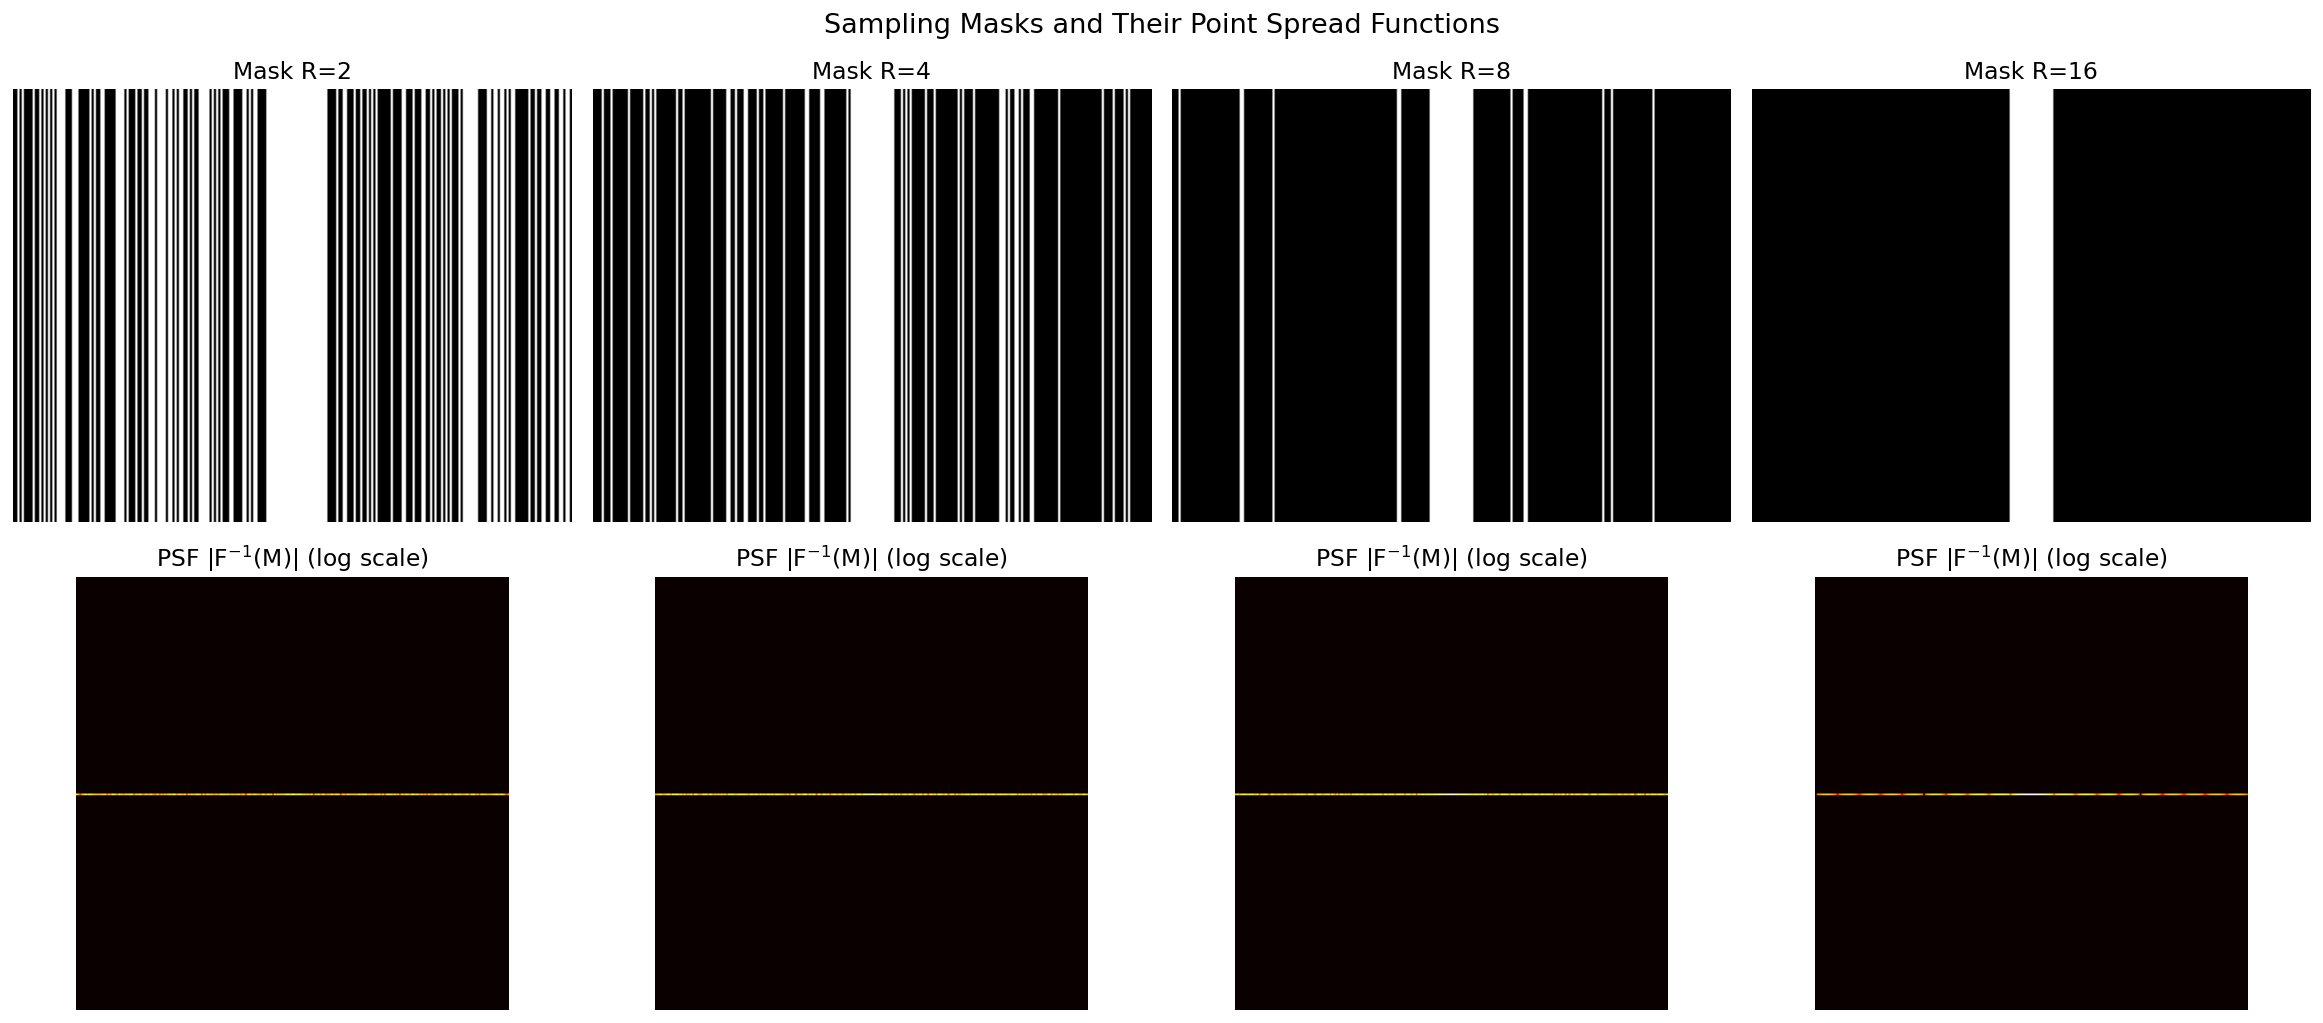

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
rng = np.random.default_rng(0)

for i, R in enumerate([2, 4, 8, 16]):
    mask = random_cartesian_mask(N, accel=R, center_frac=0.08, rng=rng)

    # PSF = IFFT of mask
    psf = np.fft.ifft2(mask, norm="ortho")
    psf_mag = np.abs(np.fft.fftshift(psf))

    axes[0, i].imshow(np.fft.fftshift(mask), cmap="gray", aspect="auto")
    axes[0, i].set_title(f"Mask R={R}"); axes[0, i].axis("off")

    # use log scale to reveal sidelobe aliasing structure
    psf_log = np.log10(psf_mag + 1e-10)
    axes[1, i].imshow(psf_log, cmap="hot", vmin=psf_log.max() - 4, vmax=psf_log.max())
    axes[1, i].set_title(f"PSF |F$^{{-1}}$(M)| (log scale)"); axes[1, i].axis("off")

fig.suptitle("Sampling Masks and Their Point Spread Functions", fontsize=15)
plt.tight_layout(); plt.show()

## 2. Monte Carlo Evaluation Over Random Masks

A single mask realization can be lucky or unlucky. We evaluate each method
over **20 independent random masks** at each acceleration factor and report
mean ± std of PSNR and SSIM.

In [8]:
# Monte Carlo over random mask realizations
N_trials = 20
Rs_mc = [2, 4, 8]

mc_results = {method: {R: {"psnr": [], "ssim": []} for R in Rs_mc}
              for method in ["ZF", "FISTA", "Unrolled"]}

for R in Rs_mc:
    for trial in range(N_trials):
        rng_trial = np.random.default_rng(trial * 1000 + R)
        mask = random_cartesian_mask(N, accel=R, center_frac=0.08, rng=rng_trial)
        y = A_np(image_np, mask)

        # Zero-fill
        zf = np.real(AT_np(y, mask))
        mc_results["ZF"][R]["psnr"].append(compute_psnr(zf, image_np))
        mc_results["ZF"][R]["ssim"].append(compute_ssim(zf, image_np))

        # FISTA (tuned)
        xf = fista_np(y, mask, K=50, step=0.3, lam=0.005)
        mc_results["FISTA"][R]["psnr"].append(compute_psnr(xf, image_np))
        mc_results["FISTA"][R]["ssim"].append(compute_ssim(xf, image_np))

        # Unrolled
        mask_t = torch.from_numpy(mask).to(device).to(torch.complex64).unsqueeze(0)
        x_t = torch.from_numpy(image_np).to(device).float()[None, None]
        with torch.no_grad():
            y_t = A_torch(x_t, mask_t)
            xu = model_perlayer(y_t, mask_t).squeeze().cpu().numpy()
        mc_results["Unrolled"][R]["psnr"].append(compute_psnr(xu, image_np))
        mc_results["Unrolled"][R]["ssim"].append(compute_ssim(xu, image_np))

    print(f"R={R} done ({N_trials} trials)")

R=2 done (20 trials)
R=4 done (20 trials)
R=8 done (20 trials)


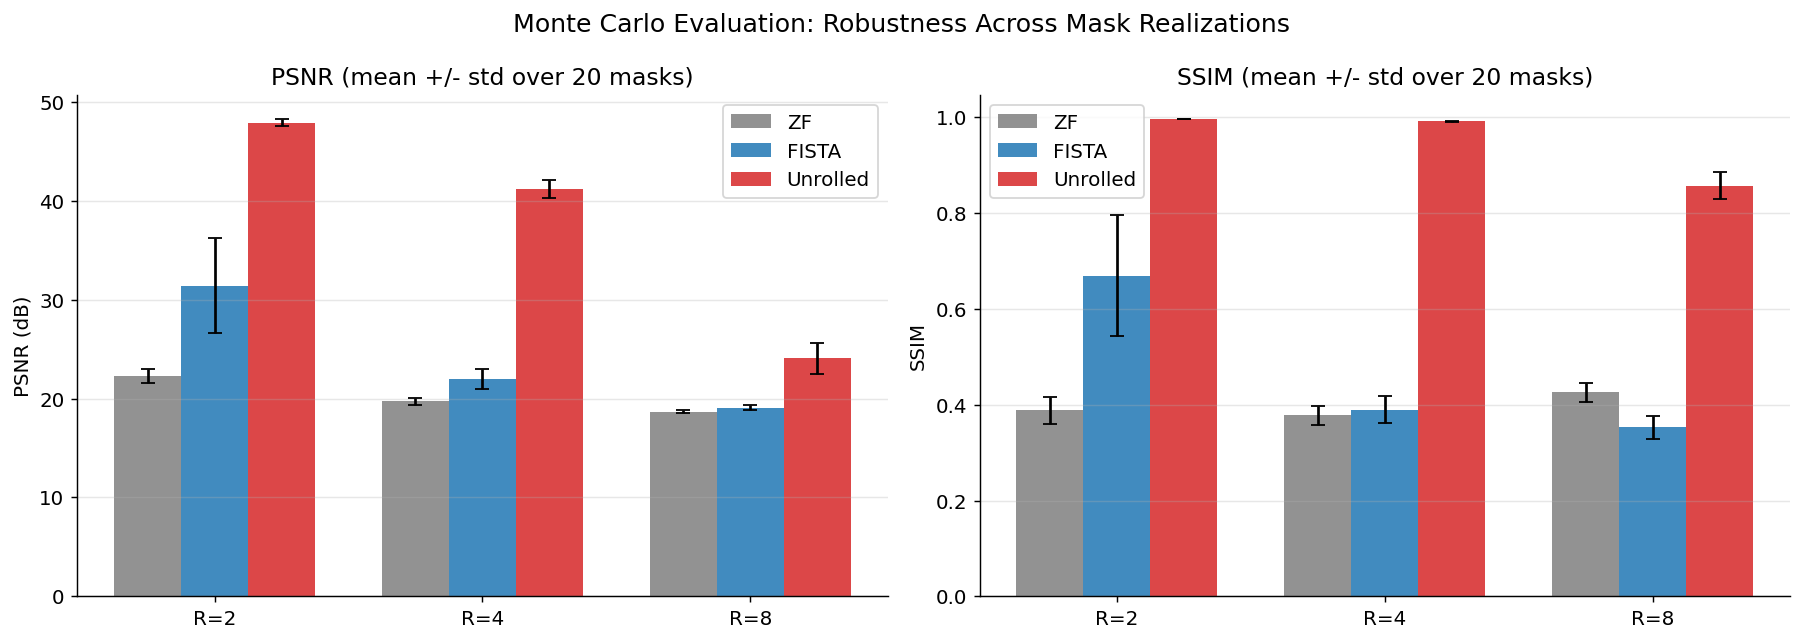


Method        R=2 PSNR         R=2 SSIM        R=4 PSNR         R=4 SSIM        R=8 PSNR         R=8 SSIM      
ZF            22.28 +/- 0.72     0.388 +/- 0.028    19.71 +/- 0.38     0.378 +/- 0.020    18.68 +/- 0.13     0.426 +/- 0.020  
FISTA         31.41 +/- 4.79     0.669 +/- 0.127    21.96 +/- 1.04     0.390 +/- 0.028    19.07 +/- 0.23     0.352 +/- 0.023  
Unrolled      47.89 +/- 0.35     0.996 +/- 0.000    41.19 +/- 0.93     0.991 +/- 0.002    24.04 +/- 1.62     0.857 +/- 0.028  


In [9]:
# Plot results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = {"ZF": "tab:gray", "FISTA": "tab:blue", "Unrolled": "tab:red"}
x_pos = np.arange(len(Rs_mc))
width = 0.25

for mi, method in enumerate(["ZF", "FISTA", "Unrolled"]):
    means_p = [np.mean(mc_results[method][R]["psnr"]) for R in Rs_mc]
    stds_p  = [np.std(mc_results[method][R]["psnr"]) for R in Rs_mc]
    means_s = [np.mean(mc_results[method][R]["ssim"]) for R in Rs_mc]
    stds_s  = [np.std(mc_results[method][R]["ssim"]) for R in Rs_mc]

    axes[0].bar(x_pos + mi * width, means_p, width, yerr=stds_p,
                label=method, color=colors[method], capsize=4, alpha=0.85)
    axes[1].bar(x_pos + mi * width, means_s, width, yerr=stds_s,
                label=method, color=colors[method], capsize=4, alpha=0.85)

axes[0].set_xticks(x_pos + width); axes[0].set_xticklabels([f"R={R}" for R in Rs_mc])
axes[0].set_ylabel("PSNR (dB)"); axes[0].set_title("PSNR (mean +/- std over 20 masks)")
axes[0].legend(); axes[0].grid(True, alpha=0.3, axis="y")

axes[1].set_xticks(x_pos + width); axes[1].set_xticklabels([f"R={R}" for R in Rs_mc])
axes[1].set_ylabel("SSIM"); axes[1].set_title("SSIM (mean +/- std over 20 masks)")
axes[1].legend(); axes[1].grid(True, alpha=0.3, axis="y")

fig.suptitle("Monte Carlo Evaluation: Robustness Across Mask Realizations", fontsize=14)
plt.tight_layout(); plt.show()



print(f"\n{'Method':<12s}", end="")
for R in Rs_mc:
    print(f"  R={R} PSNR         R={R} SSIM      ", end="")
print()
for method in ["ZF", "FISTA", "Unrolled"]:
    print(f"{method:<12s}", end="")
    for R in Rs_mc:
        mp = np.mean(mc_results[method][R]["psnr"])
        sp = np.std(mc_results[method][R]["psnr"])
        ms = np.mean(mc_results[method][R]["ssim"])
        ss = np.std(mc_results[method][R]["ssim"])
        print(f"  {mp:.2f} +/- {sp:.2f}     {ms:.3f} +/- {ss:.3f}  ", end="")
    print()

## 3. Noise Robustness Study

Real MRI measurements have noise. We add complex Gaussian noise to k-space
at various SNR levels and measure how each method degrades.

`y_noisy = M · F(x) + σ · (n_r + j·n_i)` where `σ = ||y||_F / (N · 10^{SNR/20})`

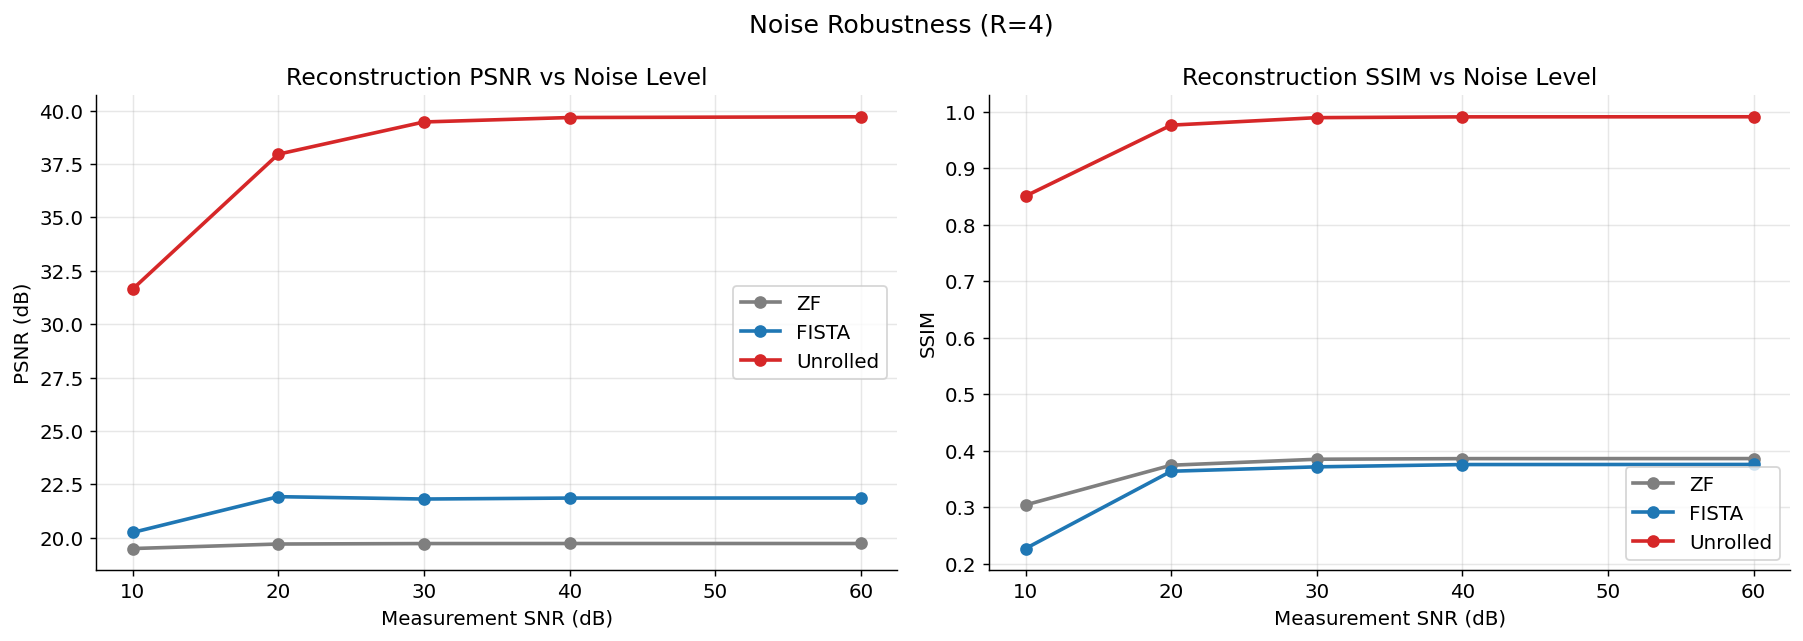

In [10]:
SNRs = [10, 20, 30, 40, 60]
R_noise = 4

noise_results = {m: {"psnr": [], "ssim": []} for m in ["ZF", "FISTA", "Unrolled"]}

rng_noise = np.random.default_rng(123)
mask_noise = random_cartesian_mask(N, accel=R_noise, center_frac=0.08, rng=rng_noise)
y_clean = A_np(image_np, mask_noise)

for snr in SNRs:
    sigma = np.linalg.norm(y_clean) / (N * 10**(snr / 20.0))
    noise = sigma * (rng_noise.standard_normal(y_clean.shape) + 1j * rng_noise.standard_normal(y_clean.shape)) / np.sqrt(2)
    y_noisy = y_clean + noise

    # Zero-fill
    zf = np.real(AT_np(y_noisy, mask_noise))
    noise_results["ZF"]["psnr"].append(compute_psnr(zf, image_np))
    noise_results["ZF"]["ssim"].append(compute_ssim(zf, image_np))

    # FISTA (slightly higher lambda for noisy data)
    lam_noisy = 0.01 if snr < 30 else 0.005
    xf = fista_np(y_noisy, mask_noise, K=50, step=0.3, lam=lam_noisy)
    noise_results["FISTA"]["psnr"].append(compute_psnr(xf, image_np))
    noise_results["FISTA"]["ssim"].append(compute_ssim(xf, image_np))

    # Unrolled — run on CPU to avoid MPS complex dtype limitation
    mask_t = torch.from_numpy(mask_noise).to("cpu").to(torch.complex64).unsqueeze(0)
    y_t = torch.from_numpy(y_noisy).to("cpu").to(torch.complex64).unsqueeze(0)
    model_perlayer.cpu()
    with torch.no_grad():
        xu = model_perlayer(y_t, mask_t).squeeze().cpu().numpy()
    model_perlayer.to(device)
    noise_results["Unrolled"]["psnr"].append(compute_psnr(xu, image_np))
    noise_results["Unrolled"]["ssim"].append(compute_ssim(xu, image_np))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for method, color in [("ZF", "tab:gray"), ("FISTA", "tab:blue"), ("Unrolled", "tab:red")]:
    axes[0].plot(SNRs, noise_results[method]["psnr"], "o-", lw=2, color=color, label=method)
    axes[1].plot(SNRs, noise_results[method]["ssim"], "o-", lw=2, color=color, label=method)

axes[0].set_xlabel("Measurement SNR (dB)"); axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("Reconstruction PSNR vs Noise Level"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Measurement SNR (dB)"); axes[1].set_ylabel("SSIM")
axes[1].set_title("Reconstruction SSIM vs Noise Level"); axes[1].legend(); axes[1].grid(True, alpha=0.3)
fig.suptitle(f"Noise Robustness (R={R_noise})", fontsize=14)
plt.tight_layout(); plt.show()

## 4. Convergence Rate Analysis

Theory predicts ISTA converges at O(1/k) and FISTA at O(1/k²). We verify
this empirically by plotting the optimality gap on a log-log scale.

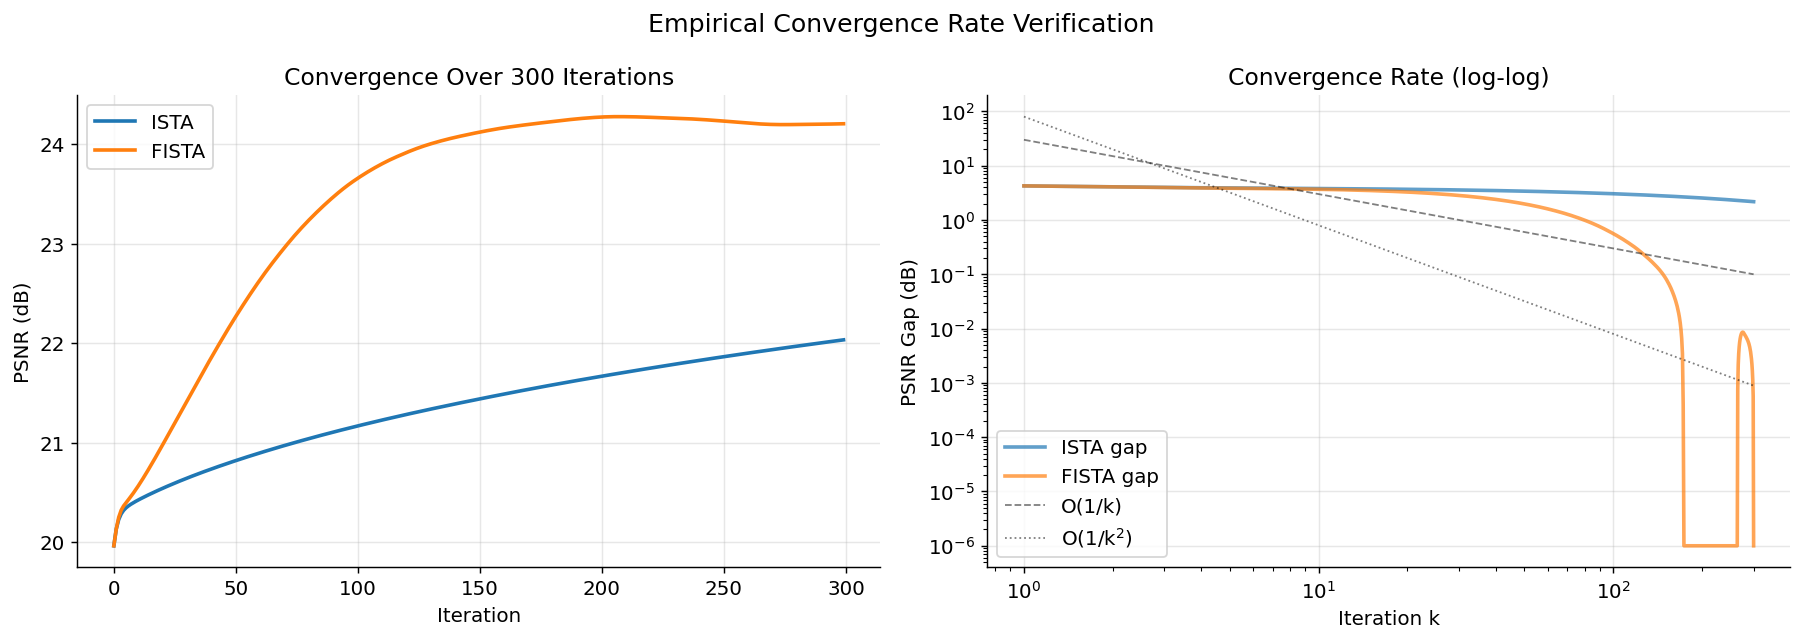

In [11]:
rng_conv = np.random.default_rng(55)
mask_conv = random_cartesian_mask(N, accel=4, center_frac=0.08, rng=rng_conv)
y_conv = A_np(image_np, mask_conv)

K_long = 300
psnr_ista_h = ista_history(y_conv, mask_conv, image_np, K=K_long, step=0.3, lam=0.005)
psnr_fista_h = fista_history(y_conv, mask_conv, image_np, K=K_long, step=0.3, lam=0.005)

# compute convergence gap: difference from final PSNR
final_psnr = max(psnr_ista_h[-1], psnr_fista_h[-1])
gap_ista = [max(final_psnr - p, 1e-6) for p in psnr_ista_h]
gap_fista = [max(final_psnr - p, 1e-6) for p in psnr_fista_h]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: PSNR convergence
axes[0].plot(psnr_ista_h, lw=2, label="ISTA")
axes[0].plot(psnr_fista_h, lw=2, label="FISTA")
axes[0].set_xlabel("Iteration"); axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title(f"Convergence Over {K_long} Iterations")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Right: Log-log optimality gap
iters = np.arange(1, K_long + 1)
axes[1].loglog(iters, gap_ista, lw=2, label="ISTA gap", alpha=0.7)
axes[1].loglog(iters, gap_fista, lw=2, label="FISTA gap", alpha=0.7)
# reference slopes
axes[1].loglog(iters, 30.0 / iters, "k--", lw=1, alpha=0.5, label="O(1/k)")
axes[1].loglog(iters, 80.0 / iters**2, "k:", lw=1, alpha=0.5, label="O(1/k$^2$)")
axes[1].set_xlabel("Iteration k"); axes[1].set_ylabel("PSNR Gap (dB)")
axes[1].set_title("Convergence Rate (log-log)")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle("Empirical Convergence Rate Verification", fontsize=14)
plt.tight_layout(); plt.show()

## 5. ROI Zoom-In Analysis

Fine structural detail is often invisible in full-image views.
We extract regions of interest (ROIs) and show magnified comparisons.

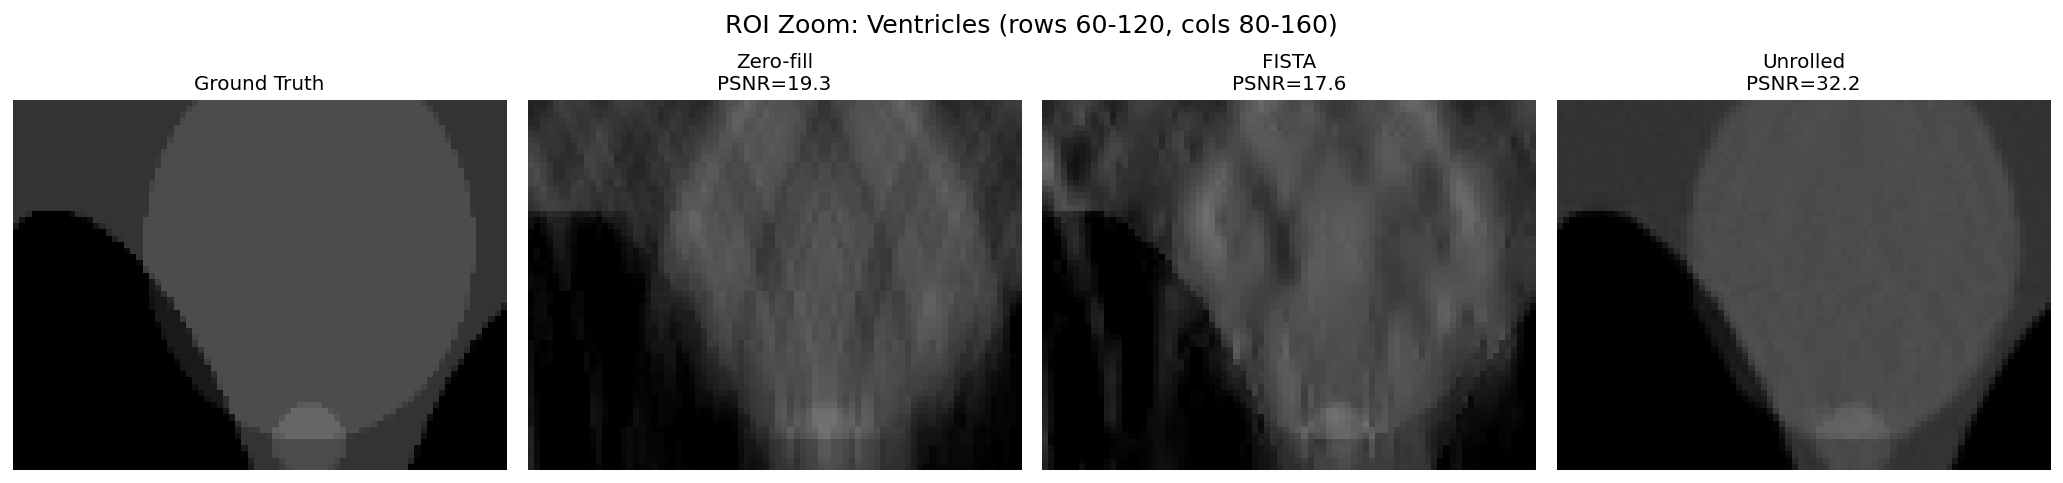

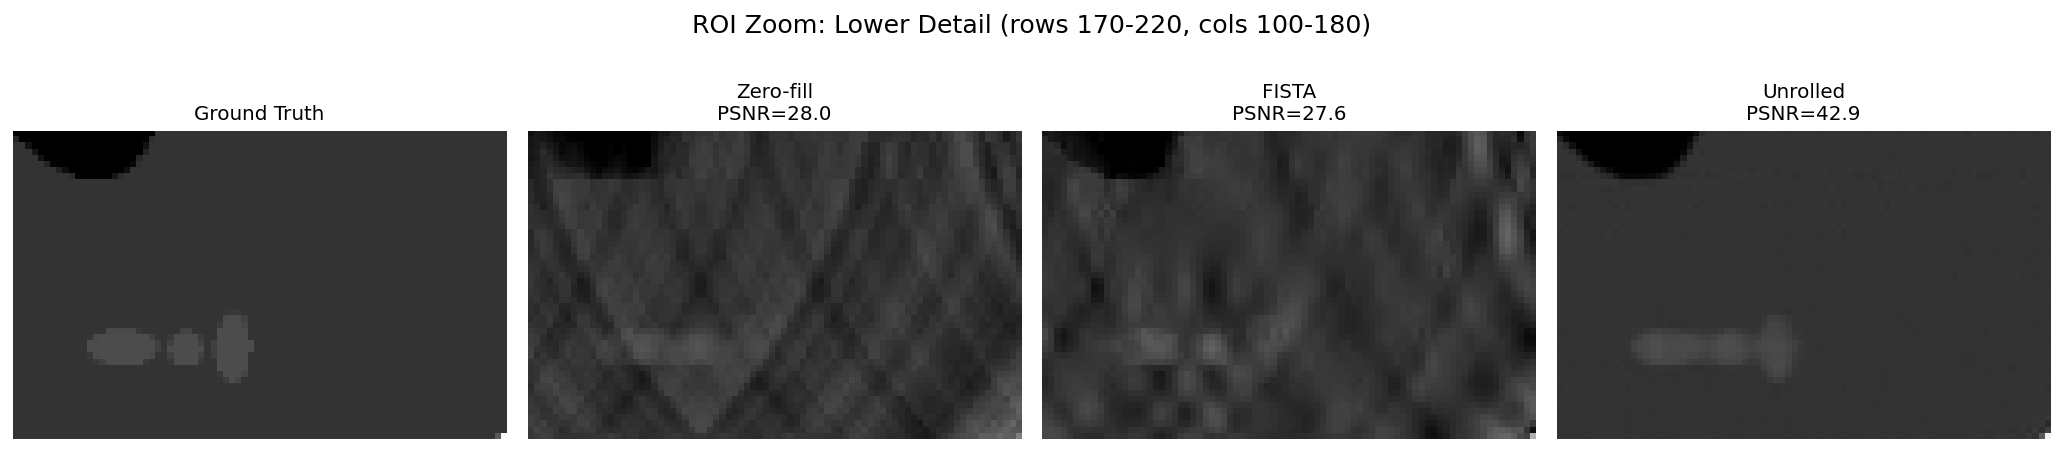

In [12]:
# ROI zoom-in comparison
rng_roi = np.random.default_rng(77)
mask_roi = random_cartesian_mask(N, accel=4, center_frac=0.08, rng=rng_roi)
y_roi = A_np(image_np, mask_roi)
zf_roi = np.real(AT_np(y_roi, mask_roi))
fista_roi = fista_np(y_roi, mask_roi, K=50, step=0.3, lam=0.005)

mask_t = torch.from_numpy(mask_roi).to(device).to(torch.complex64).unsqueeze(0)
x_t = torch.from_numpy(image_np).to(device).float()[None, None]
with torch.no_grad():
    y_t = A_torch(x_t, mask_t)
    unrolled_roi = model_perlayer(y_t, mask_t).squeeze().cpu().numpy()

# define ROIs: (row_start, row_end, col_start, col_end, label)
rois = [
    (60, 120, 80, 160, "Ventricles"),
    (170, 220, 100, 180, "Lower Detail"),
]

for r0, r1, c0, c1, label in rois:
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    vmin, vmax = image_np.min(), image_np.max()

    for ax, (img, title) in zip(axes, [
        (image_np, "Ground Truth"),
        (zf_roi, f"Zero-fill\nPSNR={compute_psnr(zf_roi[r0:r1,c0:c1], image_np[r0:r1,c0:c1]):.1f}"),
        (fista_roi, f"FISTA\nPSNR={compute_psnr(fista_roi[r0:r1,c0:c1], image_np[r0:r1,c0:c1]):.1f}"),
        (unrolled_roi, f"Unrolled\nPSNR={compute_psnr(unrolled_roi[r0:r1,c0:c1], image_np[r0:r1,c0:c1]):.1f}"),
    ]):
        ax.imshow(img[r0:r1, c0:c1], cmap="gray", vmin=vmin, vmax=vmax,
                  interpolation="nearest")
        ax.set_title(title, fontsize=11); ax.axis("off")

    fig.suptitle(f"ROI Zoom: {label} (rows {r0}-{r1}, cols {c0}-{c1})", fontsize=14)
    plt.tight_layout(); plt.show()

## 6. Ablation: Shared vs Per-Layer Proximal Operators

Does each unrolled layer need its own CNN, or can they share weights?
This is a classic parameter-efficiency question in algorithm unrolling.

Per-layer params: 26,260
Shared params:    2,635  (10.0% of per-layer)



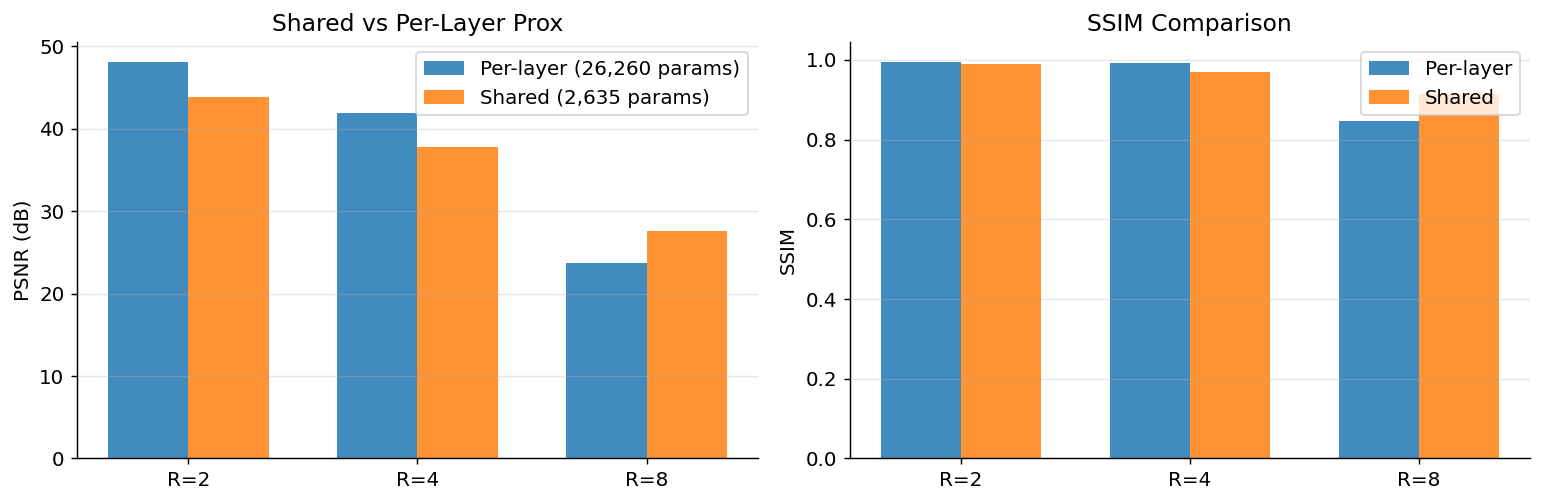

In [13]:
# evaluate both models across R values
ablation_Rs = [2, 4, 8]
ablation_results = {"Per-layer": {}, "Shared": {}}

for R in ablation_Rs:
    rng_ab = np.random.default_rng(R * 50)
    mask_ab = random_cartesian_mask(N, accel=R, center_frac=0.08, rng=rng_ab)
    mask_t = torch.from_numpy(mask_ab).to(device).to(torch.complex64).unsqueeze(0)
    x_t = torch.from_numpy(image_np).to(device).float()[None, None]

    for name, model in [("Per-layer", model_perlayer), ("Shared", model_shared)]:
        model.eval()
        with torch.no_grad():
            y_t = A_torch(x_t, mask_t)
            xu = model(y_t, mask_t).squeeze().cpu().numpy()
        ablation_results[name][R] = {
            "psnr": compute_psnr(xu, image_np),
            "ssim": compute_ssim(xu, image_np),
        }

# count params
n_perlayer = sum(p.numel() for p in model_perlayer.parameters())
n_shared = sum(p.numel() for p in model_shared.parameters())

print(f"Per-layer params: {n_perlayer:,}")
print(f"Shared params:    {n_shared:,}  ({n_shared/n_perlayer*100:.1f}% of per-layer)\n")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x_pos = np.arange(len(ablation_Rs))
w = 0.35

for mi, (name, color) in enumerate([("Per-layer", "tab:blue"), ("Shared", "tab:orange")]):
    psnrs = [ablation_results[name][R]["psnr"] for R in ablation_Rs]
    ssims = [ablation_results[name][R]["ssim"] for R in ablation_Rs]
    axes[0].bar(x_pos + mi*w, psnrs, w, label=f"{name} ({n_perlayer if name=='Per-layer' else n_shared:,} params)",
                color=color, alpha=0.85)
    axes[1].bar(x_pos + mi*w, ssims, w, label=f"{name}", color=color, alpha=0.85)

axes[0].set_xticks(x_pos + w/2); axes[0].set_xticklabels([f"R={R}" for R in ablation_Rs])
axes[0].set_ylabel("PSNR (dB)"); axes[0].set_title("Shared vs Per-Layer Prox"); axes[0].legend()
axes[0].grid(True, alpha=0.3, axis="y")

axes[1].set_xticks(x_pos + w/2); axes[1].set_xticklabels([f"R={R}" for R in ablation_Rs])
axes[1].set_ylabel("SSIM"); axes[1].set_title("SSIM Comparison"); axes[1].legend()
axes[1].grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

## 7. Acceleration Factor Sweep (All Methods)

A comprehensive view of how each method degrades with increasing acceleration.

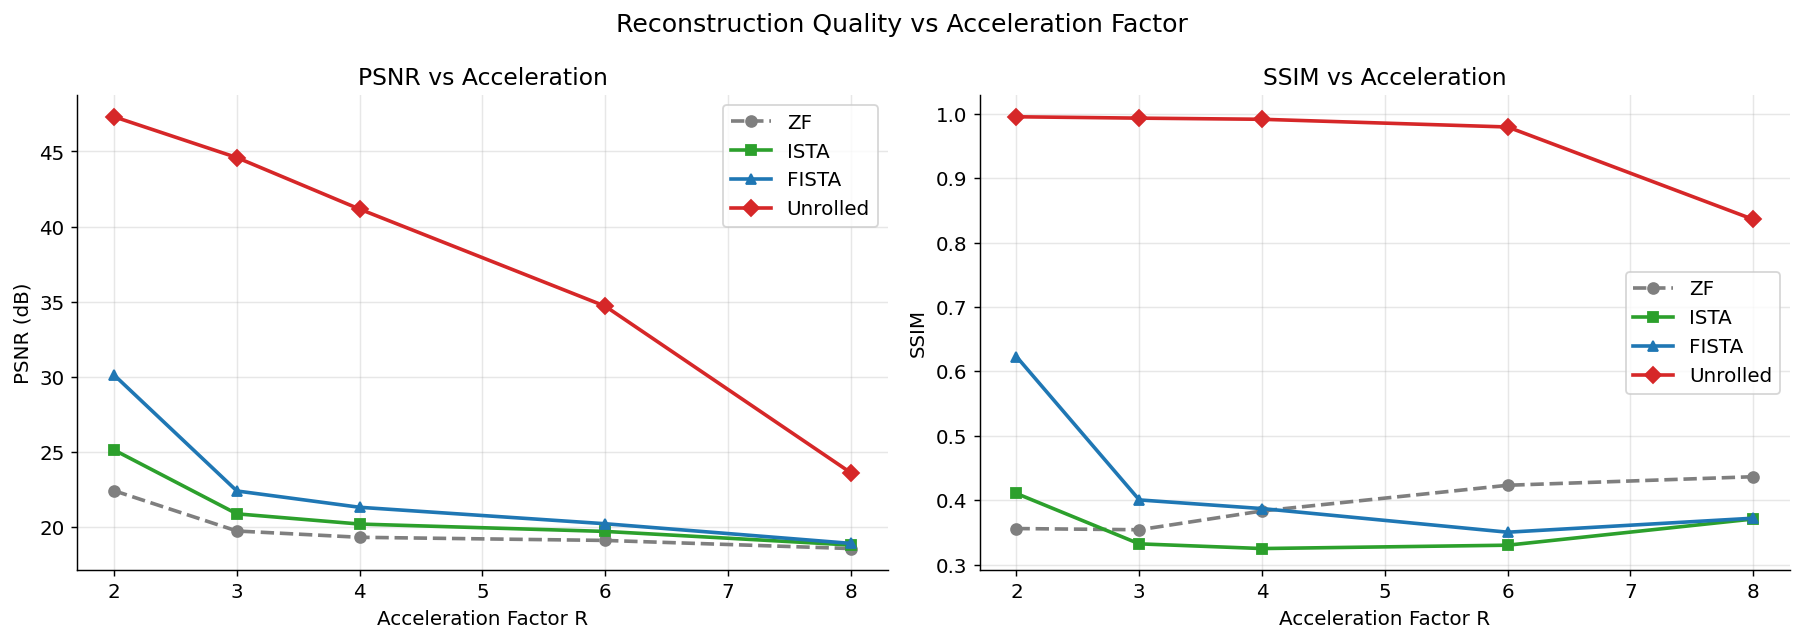

In [14]:
Rs_sweep = [2, 3, 4, 6, 8]
sweep = {m: {"psnr": [], "ssim": []} for m in ["ZF", "ISTA", "FISTA", "Unrolled"]}

for R in Rs_sweep:
    rng_s = np.random.default_rng(R * 77)
    mask_s = random_cartesian_mask(N, accel=R, center_frac=0.08, rng=rng_s)
    y_s = A_np(image_np, mask_s)

    zf_s = np.real(AT_np(y_s, mask_s))
    sweep["ZF"]["psnr"].append(compute_psnr(zf_s, image_np))
    sweep["ZF"]["ssim"].append(compute_ssim(zf_s, image_np))

    xi_s = ista_np(y_s, mask_s, K=50, step=0.3, lam=0.005)
    sweep["ISTA"]["psnr"].append(compute_psnr(xi_s, image_np))
    sweep["ISTA"]["ssim"].append(compute_ssim(xi_s, image_np))

    xf_s = fista_np(y_s, mask_s, K=50, step=0.3, lam=0.005)
    sweep["FISTA"]["psnr"].append(compute_psnr(xf_s, image_np))
    sweep["FISTA"]["ssim"].append(compute_ssim(xf_s, image_np))

    mask_t = torch.from_numpy(mask_s).to(device).to(torch.complex64).unsqueeze(0)
    x_t = torch.from_numpy(image_np).to(device).float()[None, None]
    with torch.no_grad():
        y_t = A_torch(x_t, mask_t)
        xu_s = model_perlayer(y_t, mask_t).squeeze().cpu().numpy()
    sweep["Unrolled"]["psnr"].append(compute_psnr(xu_s, image_np))
    sweep["Unrolled"]["ssim"].append(compute_ssim(xu_s, image_np))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
styles = {"ZF": ("--", "o", "tab:gray"), "ISTA": ("-", "s", "tab:green"),
          "FISTA": ("-", "^", "tab:blue"), "Unrolled": ("-", "D", "tab:red")}

for method, (ls, mk, color) in styles.items():
    axes[0].plot(Rs_sweep, sweep[method]["psnr"], ls=ls, marker=mk, color=color, lw=2, label=method)
    axes[1].plot(Rs_sweep, sweep[method]["ssim"], ls=ls, marker=mk, color=color, lw=2, label=method)

axes[0].set_xlabel("Acceleration Factor R"); axes[0].set_ylabel("PSNR (dB)")
axes[0].set_title("PSNR vs Acceleration"); axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].set_xlabel("Acceleration Factor R"); axes[1].set_ylabel("SSIM")
axes[1].set_title("SSIM vs Acceleration"); axes[1].legend(); axes[1].grid(True, alpha=0.3)

fig.suptitle("Reconstruction Quality vs Acceleration Factor", fontsize=14)
plt.tight_layout(); plt.show()

## 8. Summary Results Table

Publication-ready table summarizing all methods and conditions.

In [15]:
# summary table
print("=" * 90)
print(f"{'':60s} Phantom Reconstruction Results")
print("=" * 90)
print(f"{'Method':<20s} | {'R':>3s} | {'PSNR (dB)':>10s} | {'SSIM':>8s} | {'Notes':<30s}")
print("-" * 90)

for R in [2, 4, 8]:
    rng_t = np.random.default_rng(R * 77)
    mask_t_np = random_cartesian_mask(N, accel=R, center_frac=0.08, rng=rng_t)
    y_t_np = A_np(image_np, mask_t_np)

    zf_t = np.real(AT_np(y_t_np, mask_t_np))
    print(f"{'Zero-fill':<20s} | {R:>3d} | {compute_psnr(zf_t, image_np):>10.2f} | "
          f"{compute_ssim(zf_t, image_np):>8.4f} | {'Adjoint (baseline)':<30s}")

    xi_t = ista_np(y_t_np, mask_t_np, K=50, step=0.3, lam=0.005)
    print(f"{'ISTA (db4, K=50)':<20s} | {R:>3d} | {compute_psnr(xi_t, image_np):>10.2f} | "
          f"{compute_ssim(xi_t, image_np):>8.4f} | {'Wavelet l1, tuned':<30s}")

    xf_t = fista_np(y_t_np, mask_t_np, K=50, step=0.3, lam=0.005)
    print(f"{'FISTA (db4, K=50)':<20s} | {R:>3d} | {compute_psnr(xf_t, image_np):>10.2f} | "
          f"{compute_ssim(xf_t, image_np):>8.4f} | {'+ Nesterov momentum':<30s}")

    mask_t_torch = torch.from_numpy(mask_t_np).to(device).to(torch.complex64).unsqueeze(0)
    x_gt_torch = torch.from_numpy(image_np).to(device).float()[None, None]
    with torch.no_grad():
        y_torch = A_torch(x_gt_torch, mask_t_torch)
        xu_t = model_perlayer(y_torch, mask_t_torch).squeeze().cpu().numpy()
    print(f"{'Unrolled (K=10)':<20s} | {R:>3d} | {compute_psnr(xu_t, image_np):>10.2f} | "
          f"{compute_ssim(xu_t, image_np):>8.4f} | {'Learned CNN prox':<30s}")
    print("-" * 90)

print("\nAll results on 256×256 Shepp-Logan phantom.")
print("Classical baselines use db4 wavelet, level 4, periodic boundary.")
print("Unrolled network trained on augmented phantom data (narrow distribution).")

                                                             Phantom Reconstruction Results
Method               |   R |  PSNR (dB) |     SSIM | Notes                         
------------------------------------------------------------------------------------------
Zero-fill            |   2 |      22.42 |   0.3560 | Adjoint (baseline)            
ISTA (db4, K=50)     |   2 |      25.13 |   0.4104 | Wavelet l1, tuned             
FISTA (db4, K=50)    |   2 |      30.12 |   0.6229 | + Nesterov momentum           
Unrolled (K=10)      |   2 |      47.31 |   0.9953 | Learned CNN prox              
------------------------------------------------------------------------------------------
Zero-fill            |   4 |      19.32 |   0.3833 | Adjoint (baseline)            
ISTA (db4, K=50)     |   4 |      20.20 |   0.3249 | Wavelet l1, tuned             
FISTA (db4, K=50)    |   4 |      21.32 |   0.3870 | + Nesterov momentum           
Unrolled (K=10)      |   4 |      41.16 |   0.9914 | L

## 9. Generalization Test: Real Brain MRI

A critical question for learned reconstruction: does the unrolled network
generalize beyond its training distribution?  The model was trained exclusively
on augmented Shepp-Logan phantoms.  Here we test it on a **real T1-weighted
brain MRI slice** from scikit-image (`skimage.data.brain()`), which has
entirely different structural content — cortical folds, white/gray matter
boundaries, ventricles, and skull.

This is deliberately an **out-of-distribution** test.  We expect the classical
methods (ISTA/FISTA) to be relatively unaffected (they use no training data),
while the unrolled network may degrade since it has never seen real anatomy.

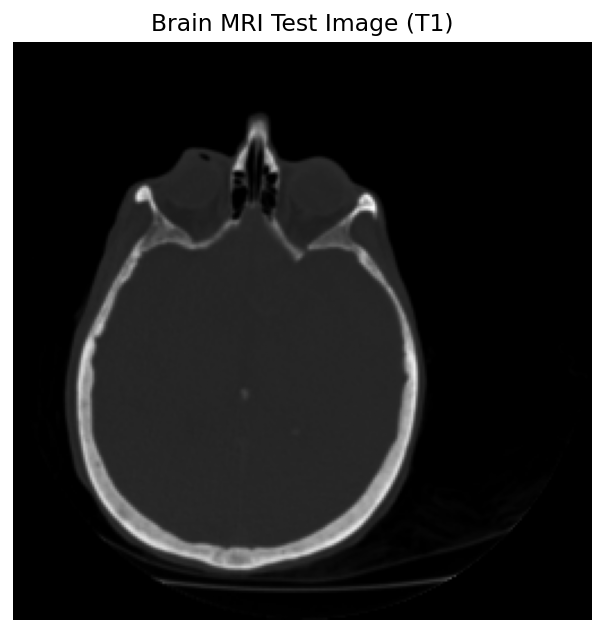

Brain slice shape: (256, 256), range: [0.000, 1.000]


In [16]:
# real brain MRI from scikit-image
from skimage.data import brain as load_brain

brain_vol = load_brain()    # (10, 256, 256) uint16 T1 slices
brain_slice = brain_vol[5].astype(np.float32)   # good mid-axial slice
brain_slice = resize(brain_slice, (256, 256), anti_aliasing=True).astype(np.float32)
brain_slice = brain_slice / brain_slice.max()   # normalize to [0, 1]

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
ax.imshow(brain_slice, cmap="gray"); ax.set_title("Brain MRI Test Image (T1)"); ax.axis("off")
plt.tight_layout(); plt.show()
print(f"Brain slice shape: {brain_slice.shape}, range: [{brain_slice.min():.3f}, {brain_slice.max():.3f}]")

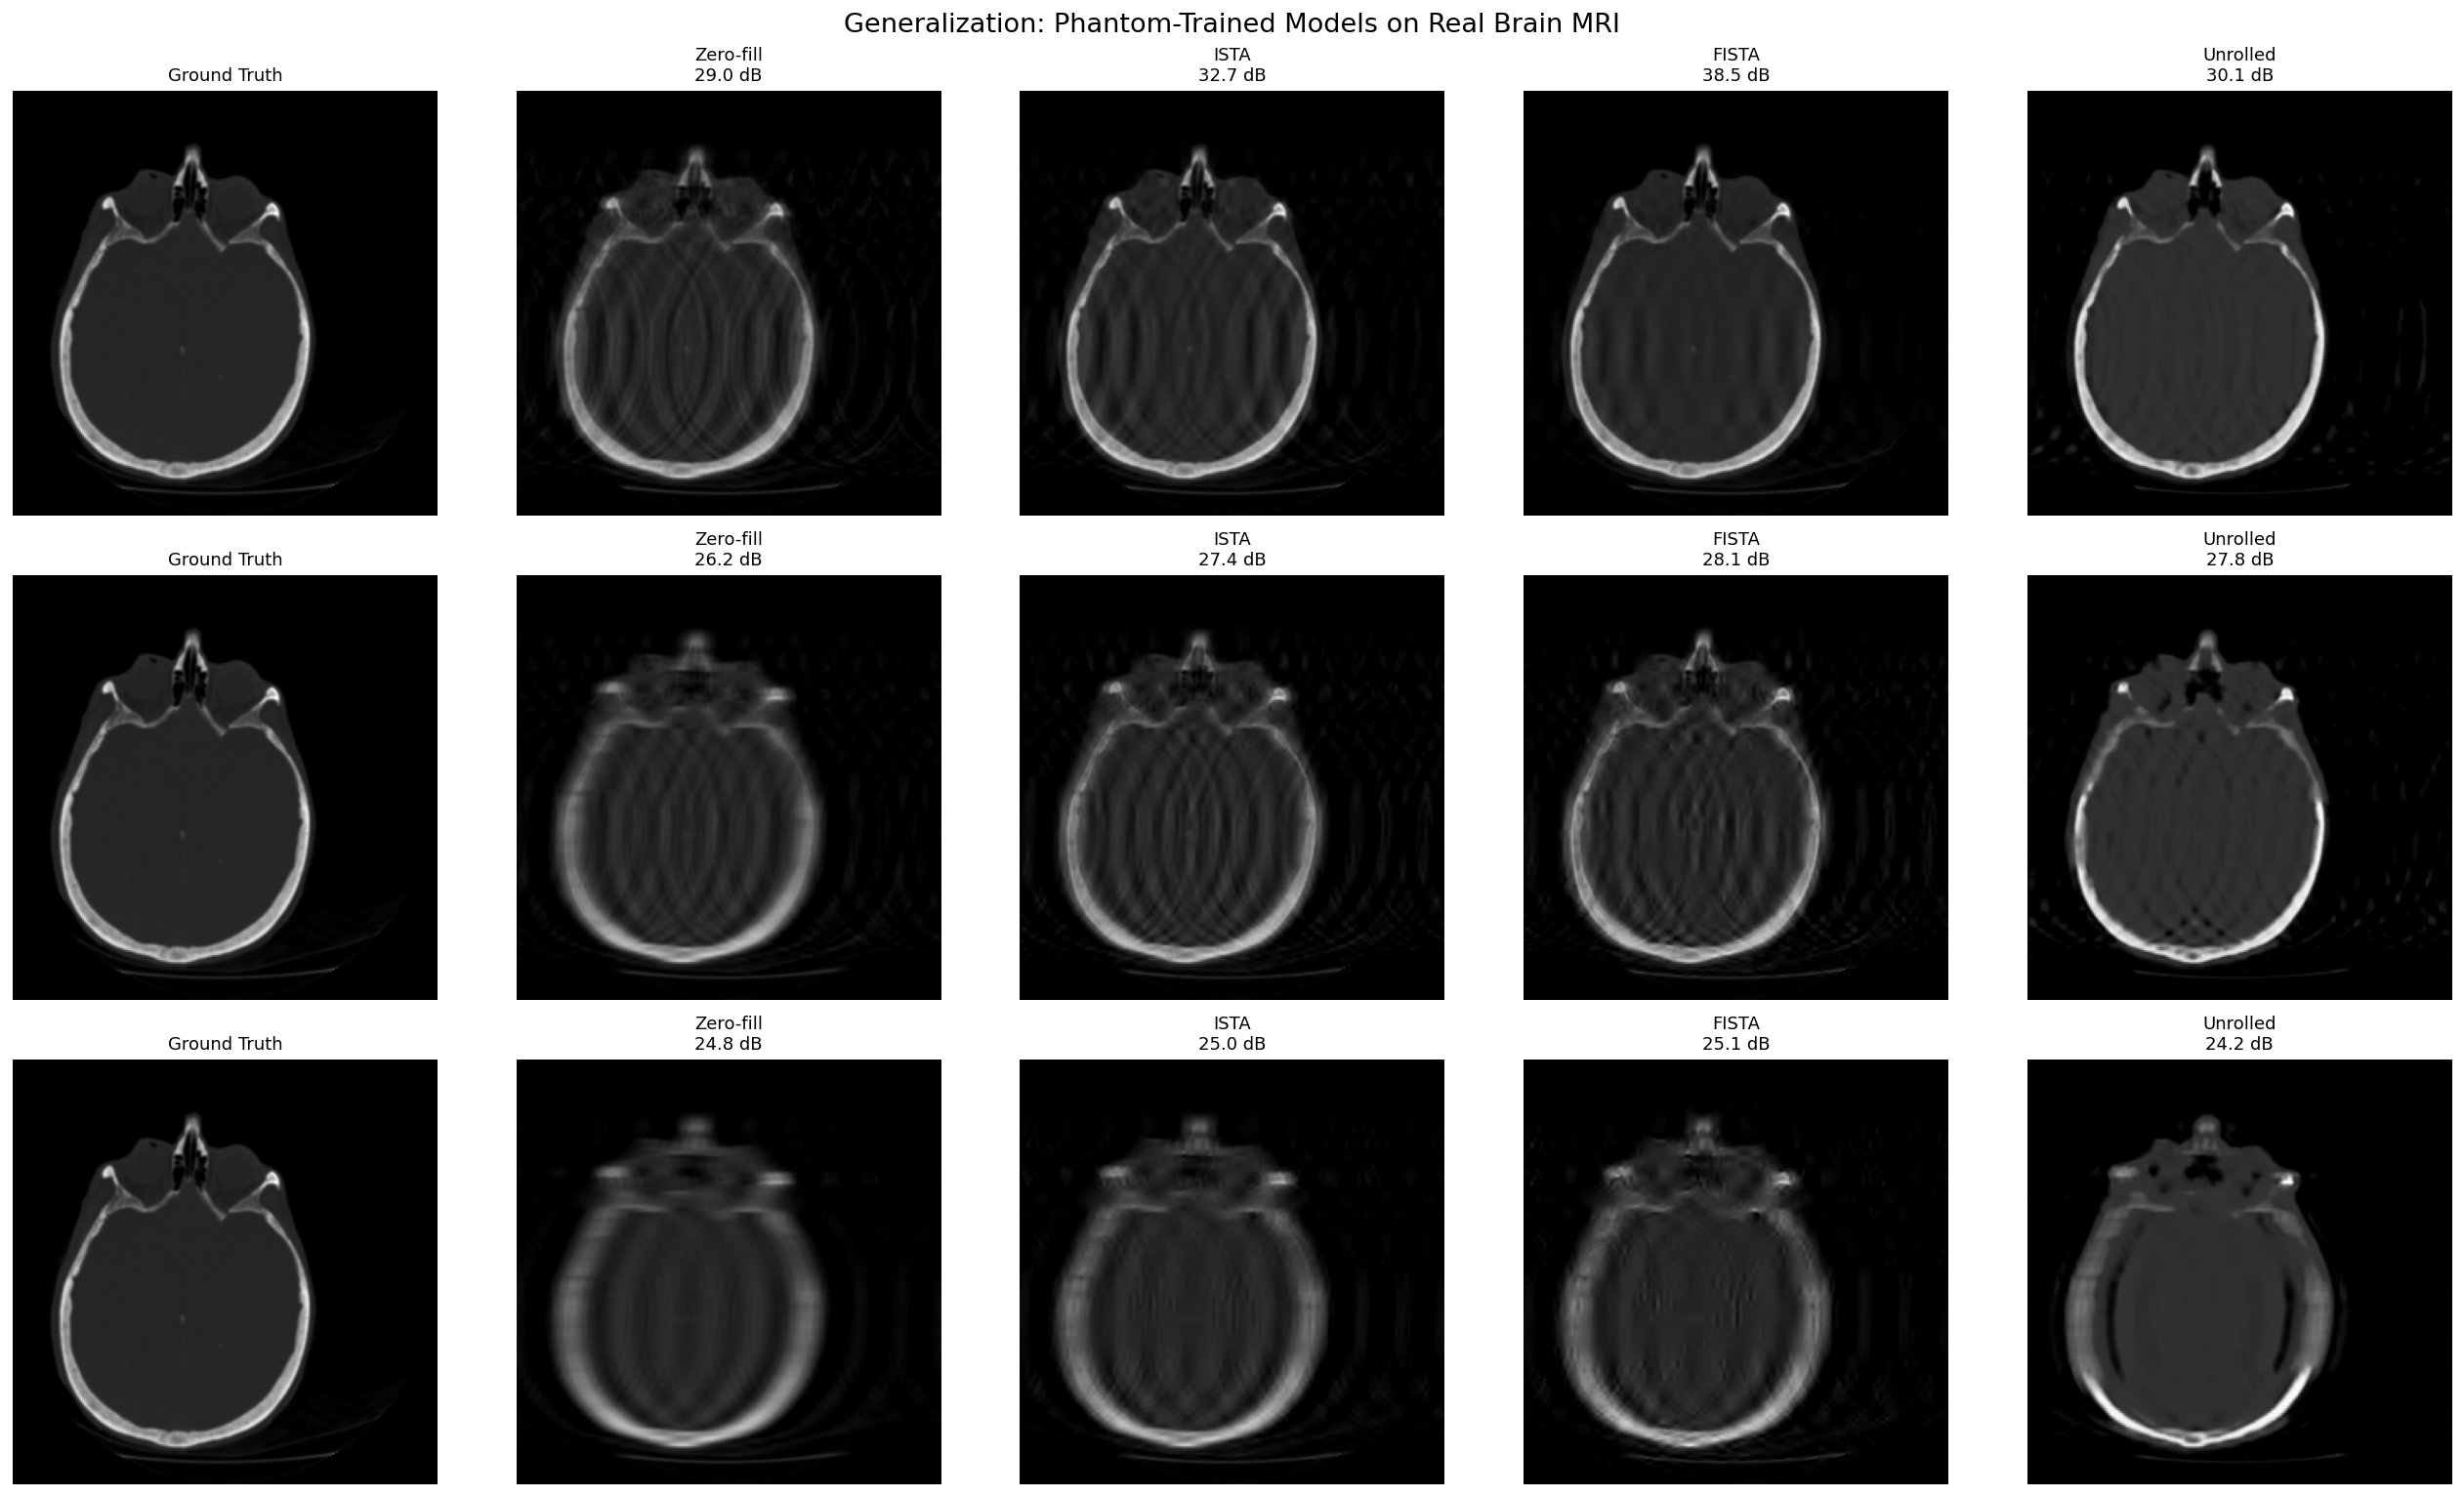

In [17]:
# Generalization comparison: Phantom-trained model on real brain MRI
gen_Rs = [2, 4, 8]
gen_results = {m: {"psnr": [], "ssim": []} for m in ["ZF", "ISTA", "FISTA", "Unrolled"]}

fig_gen, axes_gen = plt.subplots(len(gen_Rs), 5, figsize=(20, 4 * len(gen_Rs)))
vmin_b, vmax_b = brain_slice.min(), brain_slice.max()

for ri, R in enumerate(gen_Rs):
    rng_g = np.random.default_rng(R * 99)
    mask_g = random_cartesian_mask(N, accel=R, center_frac=0.08, rng=rng_g)
    y_g = A_np(brain_slice, mask_g)

    # Zero-fill
    zf_g = np.real(AT_np(y_g, mask_g))
    gen_results["ZF"]["psnr"].append(compute_psnr(zf_g, brain_slice))
    gen_results["ZF"]["ssim"].append(compute_ssim(zf_g, brain_slice))

    # ISTA
    xi_g = ista_np(y_g, mask_g, K=50, step=0.3, lam=0.005)
    gen_results["ISTA"]["psnr"].append(compute_psnr(xi_g, brain_slice))
    gen_results["ISTA"]["ssim"].append(compute_ssim(xi_g, brain_slice))

    # FISTA
    xf_g = fista_np(y_g, mask_g, K=50, step=0.3, lam=0.005)
    gen_results["FISTA"]["psnr"].append(compute_psnr(xf_g, brain_slice))
    gen_results["FISTA"]["ssim"].append(compute_ssim(xf_g, brain_slice))

    # Unrolled (trained on phantom only!)
    mask_t_g = torch.from_numpy(mask_g).to(device).to(torch.complex64).unsqueeze(0)
    x_t_g = torch.from_numpy(brain_slice).to(device).float()[None, None]
    model_perlayer.eval()
    with torch.no_grad():
        y_t_g = A_torch(x_t_g, mask_t_g)
        xu_g = model_perlayer(y_t_g, mask_t_g).squeeze().cpu().numpy()
    gen_results["Unrolled"]["psnr"].append(compute_psnr(xu_g, brain_slice))
    gen_results["Unrolled"]["ssim"].append(compute_ssim(xu_g, brain_slice))

    # Visualization row
    for ci, (img, label) in enumerate([
        (brain_slice, "Ground Truth"),
        (zf_g, f"Zero-fill\n{compute_psnr(zf_g, brain_slice):.1f} dB"),
        (xi_g, f"ISTA\n{compute_psnr(xi_g, brain_slice):.1f} dB"),
        (xf_g, f"FISTA\n{compute_psnr(xf_g, brain_slice):.1f} dB"),
        (xu_g, f"Unrolled\n{compute_psnr(xu_g, brain_slice):.1f} dB"),
    ]):
        axes_gen[ri, ci].imshow(img, cmap="gray", vmin=vmin_b, vmax=vmax_b)
        axes_gen[ri, ci].set_title(label, fontsize=10); axes_gen[ri, ci].axis("off")
    axes_gen[ri, 0].set_ylabel(f"R = {R}", fontsize=13, rotation=0, labelpad=50, va="center")

fig_gen.suptitle("Generalization: Phantom-Trained Models on Real Brain MRI", fontsize=15)
plt.tight_layout(); plt.show()

In [18]:
# summary table
print("=" * 80)
print("Generalization Test: Brain MRI (model trained on Shepp-Logan phantom only)")
print("=" * 80)
print(f"{'Method':<20s} | {'R':>3s} | {'PSNR (dB)':>10s} | {'SSIM':>8s}")
print("-" * 60)

for ri, R in enumerate(gen_Rs):
    for method in ["ZF", "ISTA", "FISTA", "Unrolled"]:
        p = gen_results[method]["psnr"][ri]
        s = gen_results[method]["ssim"][ri]
        print(f"{method:<20s} | {R:>3d} | {p:>10.2f} | {s:>8.4f}")
    print("-" * 60)

print("\nKey observation: The unrolled network was trained ONLY on Shepp-Logan")
print("phantom augmentations. Its performance on real brain anatomy reveals")
print("the generalization gap inherent in learned reconstruction methods.")
print("Classical methods (ISTA/FISTA) are data-agnostic and transfer perfectly.")

Generalization Test: Brain MRI (model trained on Shepp-Logan phantom only)
Method               |   R |  PSNR (dB) |     SSIM
------------------------------------------------------------
ZF                   |   2 |      28.98 |   0.6777
ISTA                 |   2 |      32.66 |   0.7529
FISTA                |   2 |      38.53 |   0.9000
Unrolled             |   2 |      30.13 |   0.8771
------------------------------------------------------------
ZF                   |   4 |      26.19 |   0.6711
ISTA                 |   4 |      27.36 |   0.6307
FISTA                |   4 |      28.09 |   0.6711
Unrolled             |   4 |      27.79 |   0.8363
------------------------------------------------------------
ZF                   |   8 |      24.79 |   0.6807
ISTA                 |   8 |      25.00 |   0.6569
FISTA                |   8 |      25.10 |   0.6676
Unrolled             |   8 |      24.20 |   0.7981
------------------------------------------------------------

Key observation: 